In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import os
import sklearn

In [2]:
if not os.path.exists('facial_keypoints.npz'):
  !wget -O facial_keypoints.npz "https://www.dropbox.com/scl/fi/27qggijmythfjg04s24xq/facial_keypoints.npz?rlkey=h91gwodhrfuz8hrc7ux9qnq7s&dl=1"

In [3]:
data = np.load('facial_keypoints.npz')
images = data['images']
keypoints = data['keypoints']

In [4]:
print(f'images is {images.shape} of dtype {images.dtype} with min {np.min(images)} and max {np.max(images)}')
print(f'keypoints is {keypoints.shape} of dtype {keypoints.dtype} with {np.nanmin(keypoints, )} and max {np.nanmax(keypoints)}')

images is (7049, 1, 96, 96) of dtype int64 with min 0 and max 255
keypoints is (7049, 30) of dtype float32 with 0.6865919828414917 and max 95.9356460571289


Text(0.5, 1.0, 'Image 50')

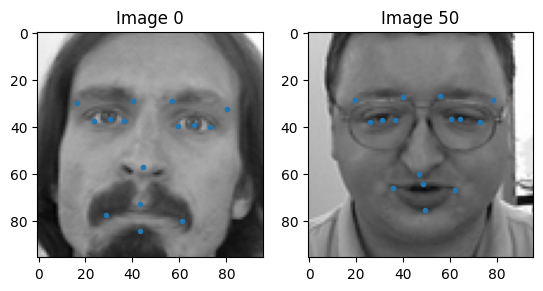

In [5]:
fig, axes = plt.subplots(1,2)

axes[0].imshow(images[0].transpose(1,2,0), cmap='gray')
axes[0].plot(keypoints[0][::2], keypoints[0][1::2], '.')
axes[0].set_title('Image 0')

axes[1].imshow(images[50].transpose(1,2,0), cmap='gray')
axes[1].plot(keypoints[50][::2], keypoints[50][1::2], '.')
axes[1].set_title('Image 50')

In [6]:
from sklearn.preprocessing import MinMaxScaler

X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(images, keypoints, train_size=0.9, random_state=0)
X_train = X_train / 255.0  # scale down for easier training (since already 64 bit dtype)
X_test = X_test / 255.0  # scale down for easier training (since already 64 bit dtype)

keypoint_scaler = MinMaxScaler().fit(y_train)
# keypoint_scaler = MinMaxScaler(feature_range=(0,96)).fit(y_train)
y_train = keypoint_scaler.transform(y_train)
y_test = keypoint_scaler.transform(y_test)

X_train[0].dtype, y_test[0], np.nanmax(y_test)

(dtype('float64'),
 array([0.67174184, 0.48129743, 0.30402058, 0.4400528 ,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
        0.44999593, 0.6649189 ,        nan,        nan,        nan,
               nan,        nan,        nan, 0.44794244, 0.7922044 ],
       dtype=float32),
 np.float32(1.5506192))

In [7]:
X_train_torch = torch.tensor(X_train).float()
y_train_torch = torch.tensor(y_train)
X_test_torch = torch.tensor(X_test).float()
y_test_torch = torch.tensor(y_test) 

In [8]:
from torch.utils.data import TensorDataset, DataLoader

train_ds = TensorDataset(X_train_torch, y_train_torch)
test_ds = TensorDataset(X_test_torch, y_test_torch)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [10]:
import torch.nn as nn

# vgg style architecture
model = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding='same'),
    nn.ReLU(),
    nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding='same'),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    
    nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding='same'),
    nn.ReLU(),
    nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding='same'),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding='same'),
    nn.ReLU(),
    nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding='same'),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Flatten(),

    nn.Linear(128 * 12 * 12, 30),
    # nn.ReLU(),
    # nn.Linear(73728*2, 30)
)

model = model.to(device)

In [11]:
def masked_mae_loss(y_pred,y_true):
    mask = 1-torch.isnan(y_true).float()
    diff = torch.abs(y_true-y_pred)
    return torch.nansum(diff*mask)/torch.nansum(mask)

In [ ]:
def masked_mse_loss(y_pred,y_true):
    mask = 1-torch.isnan(y_true).float()
    diff = torch.square(y_true-y_pred)
    return torch.nansum(diff*mask)/torch.nansum(mask)

In [ ]:
loss_fn = masked_mae_loss
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

train_loss = []
test_loss = []
epochs = 50
for epoch in range(epochs):
    # training phase
    model.train()
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        opt.zero_grad() # zero out the gradients
        z_batch = model(X_batch) # compute z values
        loss = loss_fn(z_batch,y_batch) # compute loss
        loss.backward() # compute gradients
        opt.step() # apply gradients
    train_loss.append(loss.item())

    # eval phase
    model.eval()
    epoch_test_loss = 0
    with torch.no_grad(): # Disable gradient calculation
        for t_X_batch, t_y_batch in test_loader:
            t_X_batch, t_y_batch = t_X_batch.to(device), t_y_batch.to(device)
            t_z_batch = model(t_X_batch)
            t_loss = loss_fn(t_z_batch, t_y_batch)
            epoch_test_loss += t_loss.item()
    
    # 4. Average and save the test loss
    avg_test_loss = epoch_test_loss / len(test_loader)
    test_loss.append(avg_test_loss)
    
    print(f'epoch {epoch}: train_loss {loss.item():.4f} | test_loss {avg_test_loss:.4f}')

epoch 0: train_loss 0.0464 | test_loss 0.0459
epoch 1: train_loss 0.0330 | test_loss 0.0374
epoch 2: train_loss 0.0281 | test_loss 0.0295
epoch 3: train_loss 0.0229 | test_loss 0.0268
epoch 4: train_loss 0.0257 | test_loss 0.0243
epoch 5: train_loss 0.0171 | test_loss 0.0252
epoch 6: train_loss 0.0203 | test_loss 0.0275
epoch 7: train_loss 0.0308 | test_loss 0.0253
epoch 8: train_loss 0.0346 | test_loss 0.0242
epoch 9: train_loss 0.0367 | test_loss 0.0229
epoch 10: train_loss 0.0146 | test_loss 0.0225
epoch 11: train_loss 0.0179 | test_loss 0.0222
epoch 12: train_loss 0.0241 | test_loss 0.0231
epoch 13: train_loss 0.0250 | test_loss 0.0219
epoch 14: train_loss 0.0191 | test_loss 0.0215
epoch 15: train_loss 0.0182 | test_loss 0.0225
epoch 16: train_loss 0.0185 | test_loss 0.0239
epoch 17: train_loss 0.0214 | test_loss 0.0209
epoch 18: train_loss 0.0167 | test_loss 0.0254
epoch 19: train_loss 0.0134 | test_loss 0.0226
epoch 20: train_loss 0.0338 | test_loss 0.0221
epoch 21: train_loss 0.

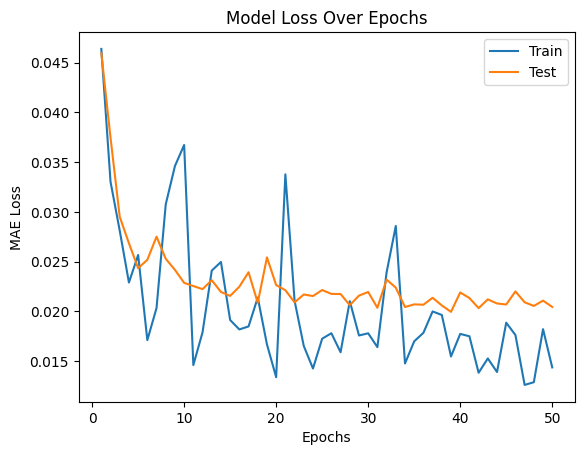

In [ ]:
epochs_range = np.arange(1,51)
plt.figure()
plt.plot(epochs_range, train_loss, label='Train')
plt.plot(epochs_range, test_loss, label='Test')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('MAE Loss')
plt.legend()
plt.show()

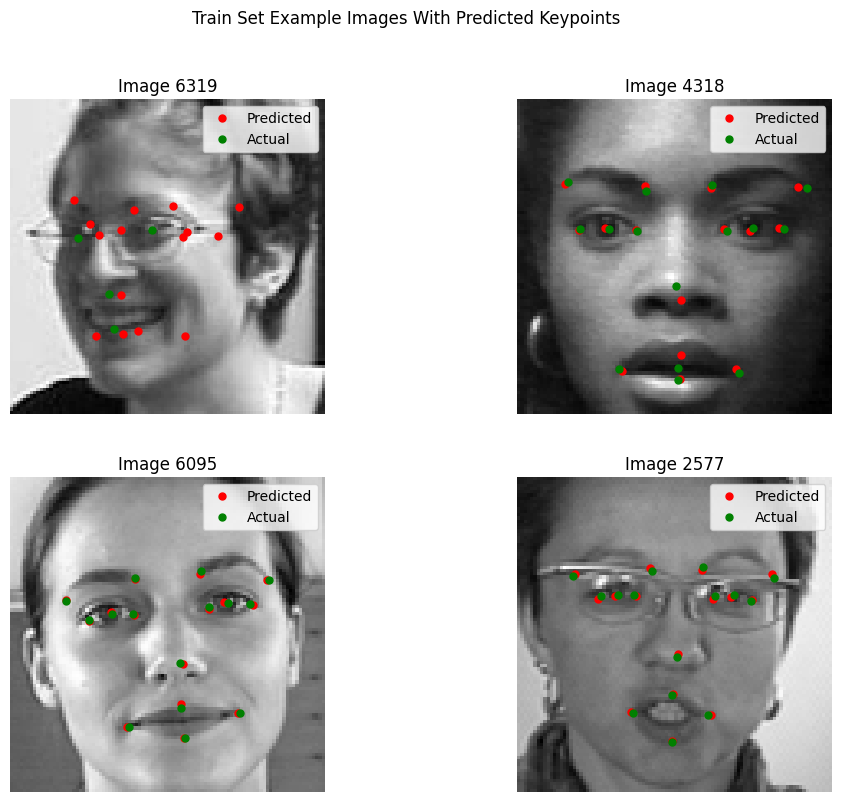

In [ ]:
# analyze train results
import random

inds = random.sample(range(len(y_train)), 4)
ctr = 0
fig, axes = plt.subplots(2,2, figsize=(12,9))
for i in range(2):
    for j in range(2):
        k = inds[ctr]
            
        # Prediction processing
        kps_pred = model(X_train_torch[k].unsqueeze(0).to(device))
        kps_pred_np = kps_pred.detach().cpu().numpy().reshape(1, -1)
        # Flatten to 1D after inverse transform for easier plotting
        kps_pred_flat = keypoint_scaler.inverse_transform(kps_pred_np).flatten()
        
        # Actual processing (handling potential tensor/numpy mix)
        y_actual_raw = y_train[k].cpu().numpy() if torch.is_tensor(y_train[k]) else y_train[k]
        kps_act_flat = keypoint_scaler.inverse_transform(y_actual_raw.reshape(1, -1)).flatten()

        # Plotting
        axes[i,j].imshow(X_train[k].transpose(1, 2, 0).squeeze(), cmap='gray')
        axes[i,j].plot(kps_pred_flat[0::2], kps_pred_flat[1::2], 'ro', label='Predicted', markersize=5)
        axes[i,j].plot(kps_act_flat[0::2], kps_act_flat[1::2], 'go', label='Actual', markersize=5)
        
        axes[i,j].set_title(f'Image {k}')
        axes[i,j].legend()
        axes[i,j].axis('off') # Clean up the look

        ctr += 1

fig.suptitle('Train Set Example Images With Predicted Keypoints')
plt.show()

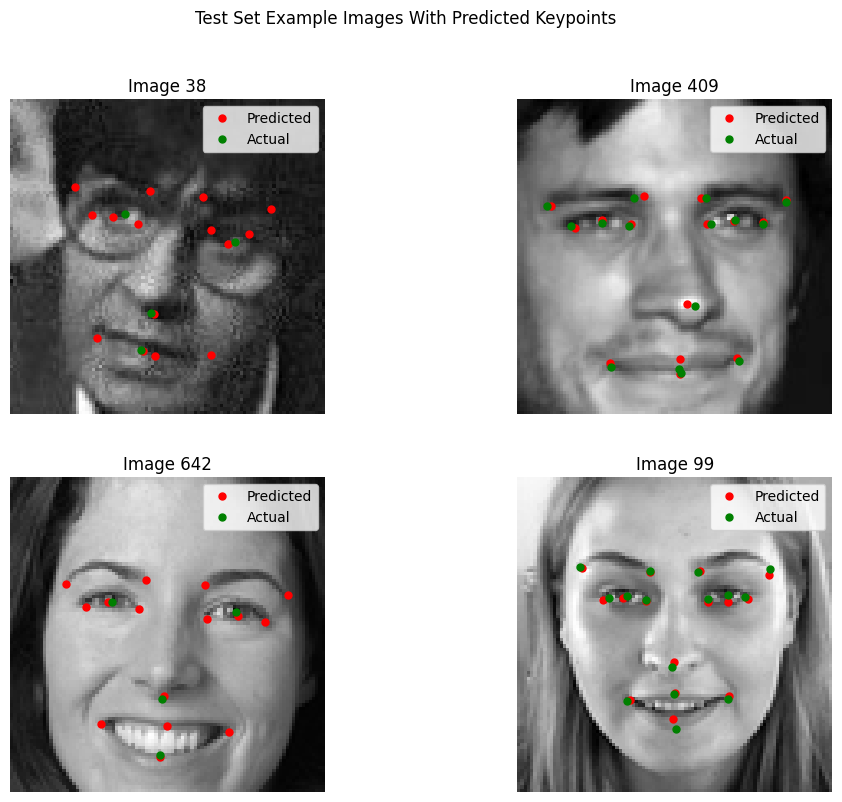

In [ ]:
# analyze test results
inds = random.sample(range(len(y_test)), 4)
ctr = 0
fig, axes = plt.subplots(2,2, figsize=(12,9))
for i in range(2):
    for j in range(2):
        k = inds[ctr]
            
        # Prediction processing
        kps_pred = model(X_test_torch[k].unsqueeze(0).to(device))
        kps_pred_np = kps_pred.detach().cpu().numpy().reshape(1, -1)
        # Flatten to 1D after inverse transform for easier plotting
        kps_pred_flat = keypoint_scaler.inverse_transform(kps_pred_np).flatten()
        
        # Actual processing (handling potential tensor/numpy mix)
        y_actual_raw = y_test[k].cpu().numpy() if torch.is_tensor(y_test[k]) else y_test[k]
        kps_act_flat = keypoint_scaler.inverse_transform(y_actual_raw.reshape(1, -1)).flatten()

        # Plotting
        axes[i,j].imshow(X_test[k].transpose(1, 2, 0).squeeze(), cmap='gray')
        axes[i,j].plot(kps_pred_flat[0::2], kps_pred_flat[1::2], 'ro', label='Predicted', markersize=5)
        axes[i,j].plot(kps_act_flat[0::2], kps_act_flat[1::2], 'go', label='Actual', markersize=5)
        
        axes[i,j].set_title(f'Image {k}')
        axes[i,j].legend()
        axes[i,j].axis('off') # Clean up the look

        ctr += 1

fig.suptitle('Test Set Example Images With Predicted Keypoints')
plt.show()

## 7. Improvement Modifications

In [ ]:
# same VGG-style architecture but adding more MLP layers
model1 = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding='same'),
    nn.ReLU(),
    nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding='same'),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    
    nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding='same'),
    nn.ReLU(),
    nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding='same'),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding='same'),
    nn.ReLU(),
    nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding='same'),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Flatten(),

    nn.Linear(128 * 12 * 12, 128*12*12*2),
    nn.ReLU(),
    nn.Linear(128*12*12*2, 30)
)

model1 = model1.to(device)

In [14]:
loss_fn = masked_mae_loss
opt1 = torch.optim.Adam(model1.parameters(), lr=1e-3, weight_decay=1e-4)

train_loss1 = []
test_loss1 = []
epochs = 50
for epoch in range(epochs):
    # training phase
    model1.train()
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        opt1.zero_grad() # zero out the gradients
        z_batch = model1(X_batch) # compute z values
        loss = loss_fn(z_batch,y_batch) # compute loss
        loss.backward() # compute gradients
        opt1.step() # apply gradients
    train_loss1.append(loss.item())

    # eval phase
    model1.eval()
    epoch_test_loss = 0
    with torch.no_grad(): # Disable gradient calculation
        for t_X_batch, t_y_batch in test_loader:
            t_X_batch, t_y_batch = t_X_batch.to(device), t_y_batch.to(device)
            t_z_batch = model1(t_X_batch)
            t_loss = loss_fn(t_z_batch, t_y_batch)
            epoch_test_loss += t_loss.item()
    
    # 4. Average and save the test loss
    avg_test_loss = epoch_test_loss / len(test_loader)
    test_loss1.append(avg_test_loss)
    
    print(f'epoch {epoch}: train_loss {loss.item():.4f} | test_loss {avg_test_loss:.4f}')

epoch 0: train_loss 0.0533 | test_loss 0.0485
epoch 1: train_loss 0.0414 | test_loss 0.0459
epoch 2: train_loss 0.0351 | test_loss 0.0506
epoch 3: train_loss 0.0576 | test_loss 0.0469
epoch 4: train_loss 0.0427 | test_loss 0.0456
epoch 5: train_loss 0.0439 | test_loss 0.0464
epoch 6: train_loss 0.0426 | test_loss 0.0456
epoch 7: train_loss 0.0508 | test_loss 0.0457
epoch 8: train_loss 0.0462 | test_loss 0.0482
epoch 9: train_loss 0.0688 | test_loss 0.0456
epoch 10: train_loss 0.0616 | test_loss 0.0457


KeyboardInterrupt: 

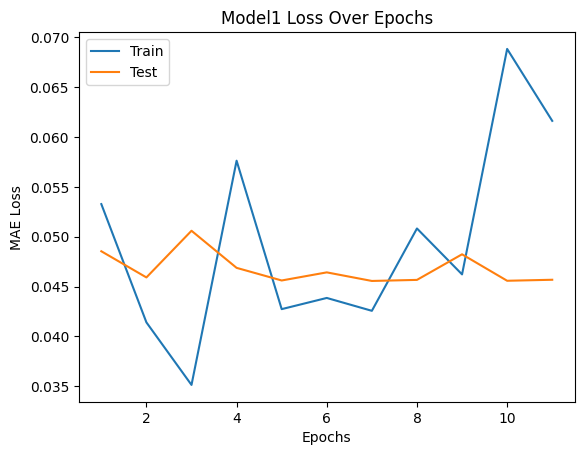

In [19]:
epochs_range = np.arange(1,12)
plt.figure()
plt.plot(epochs_range, train_loss1, label='Train')
plt.plot(epochs_range, test_loss1, label='Test')
plt.title('Model1 Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('MAE Loss')
plt.legend()
plt.show()

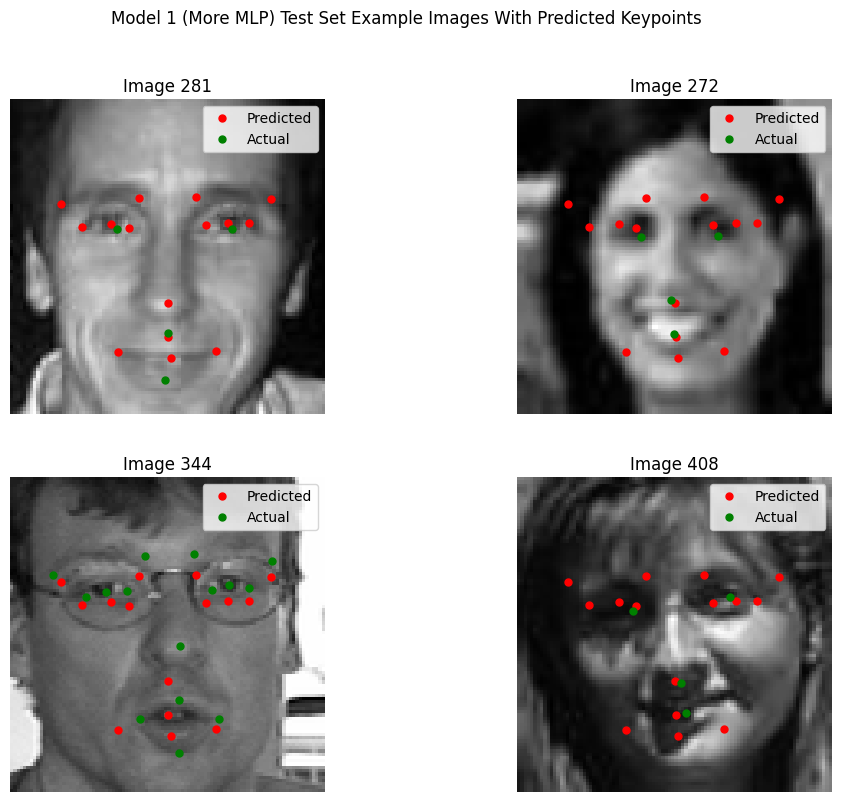

In [21]:
# analyze test results
import random
inds = random.sample(range(len(y_test)), 4)
ctr = 0
fig, axes = plt.subplots(2,2, figsize=(12,9))
for i in range(2):
    for j in range(2):
        k = inds[ctr]
            
        # Prediction processing
        kps_pred = model1(X_test_torch[k].unsqueeze(0).to(device))
        kps_pred_np = kps_pred.detach().cpu().numpy().reshape(1, -1)
        # Flatten to 1D after inverse transform for easier plotting
        kps_pred_flat = keypoint_scaler.inverse_transform(kps_pred_np).flatten()
        
        # Actual processing (handling potential tensor/numpy mix)
        y_actual_raw = y_test[k].cpu().numpy() if torch.is_tensor(y_test[k]) else y_test[k]
        kps_act_flat = keypoint_scaler.inverse_transform(y_actual_raw.reshape(1, -1)).flatten()

        # Plotting
        axes[i,j].imshow(X_test[k].transpose(1, 2, 0).squeeze(), cmap='gray')
        axes[i,j].plot(kps_pred_flat[0::2], kps_pred_flat[1::2], 'ro', label='Predicted', markersize=5)
        axes[i,j].plot(kps_act_flat[0::2], kps_act_flat[1::2], 'go', label='Actual', markersize=5)
        
        axes[i,j].set_title(f'Image {k}')
        axes[i,j].legend()
        axes[i,j].axis('off') # Clean up the look

        ctr += 1

fig.suptitle('Model 1 (More MLP) Test Set Example Images With Predicted Keypoints')
plt.show()

In [24]:
# same VGG-style architecture but adding two more conv-conv-maxpool sections
model2 = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding='same'),
    nn.ReLU(),
    nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding='same'),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    
    nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding='same'),
    nn.ReLU(),
    nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding='same'),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    # nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding='same'),
    # nn.ReLU(),
    # nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding='same'),
    # nn.ReLU(),
    # nn.MaxPool2d(kernel_size=2, stride=2),

    # nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding='same'),
    # nn.ReLU(),
    # nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding='same'),
    # nn.ReLU(),
    # nn.MaxPool2d(kernel_size=2, stride=2),

    # nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding='same'),
    # nn.ReLU(),
    # nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding='same'),
    # nn.ReLU(),
    # nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Flatten(),
    nn.Linear(64*24*24, 30)
)

model2 = model2.to(device)

In [25]:
loss_fn = masked_mae_loss
opt2 = torch.optim.Adam(model2.parameters(), lr=1e-3, weight_decay=1e-4)

train_loss2 = []
test_loss2 = []
epochs = 50
for epoch in range(epochs):
    # training phase
    model2.train()
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        opt2.zero_grad() # zero out the gradients
        z_batch = model2(X_batch) # compute z values
        loss = loss_fn(z_batch,y_batch) # compute loss
        loss.backward() # compute gradients
        opt2.step() # apply gradients
    train_loss2.append(loss.item())

    # eval phase
    model2.eval()
    epoch_test_loss = 0
    with torch.no_grad(): # Disable gradient calculation
        for t_X_batch, t_y_batch in test_loader:
            t_X_batch, t_y_batch = t_X_batch.to(device), t_y_batch.to(device)
            t_z_batch = model2(t_X_batch)
            t_loss = loss_fn(t_z_batch, t_y_batch)
            epoch_test_loss += t_loss.item()
    
    # 4. Average and save the test loss
    avg_test_loss = epoch_test_loss / len(test_loader)
    test_loss2.append(avg_test_loss)
    
    print(f'epoch {epoch}: train_loss {loss.item():.4f} | test_loss {avg_test_loss:.4f}')

epoch 0: train_loss 0.0425 | test_loss 0.0414
epoch 1: train_loss 0.0390 | test_loss 0.0396
epoch 2: train_loss 0.0285 | test_loss 0.0291
epoch 3: train_loss 0.0236 | test_loss 0.0280
epoch 4: train_loss 0.0171 | test_loss 0.0258
epoch 5: train_loss 0.0360 | test_loss 0.0243
epoch 6: train_loss 0.0422 | test_loss 0.0261
epoch 7: train_loss 0.0188 | test_loss 0.0247
epoch 8: train_loss 0.0233 | test_loss 0.0245
epoch 9: train_loss 0.0240 | test_loss 0.0246
epoch 10: train_loss 0.0163 | test_loss 0.0245
epoch 11: train_loss 0.0280 | test_loss 0.0257
epoch 12: train_loss 0.0151 | test_loss 0.0236
epoch 13: train_loss 0.0204 | test_loss 0.0240
epoch 14: train_loss 0.0245 | test_loss 0.0233
epoch 15: train_loss 0.0177 | test_loss 0.0248
epoch 16: train_loss 0.0147 | test_loss 0.0239
epoch 17: train_loss 0.0176 | test_loss 0.0251
epoch 18: train_loss 0.0186 | test_loss 0.0236
epoch 19: train_loss 0.0172 | test_loss 0.0238
epoch 20: train_loss 0.0212 | test_loss 0.0234
epoch 21: train_loss 0.

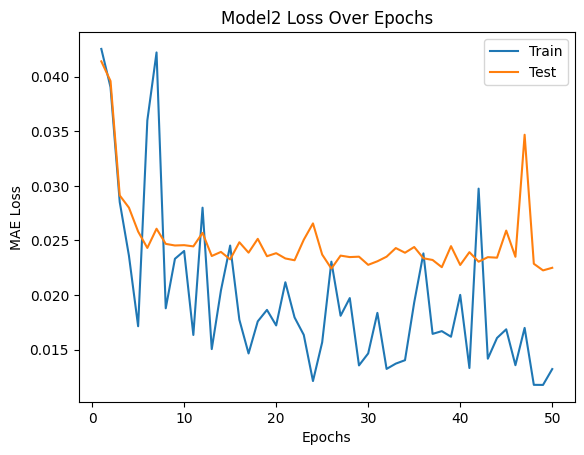

In [26]:
epochs_range = np.arange(1,51)
plt.figure()
plt.plot(epochs_range, train_loss2, label='Train')
plt.plot(epochs_range, test_loss2, label='Test')
plt.title('Model2 Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('MAE Loss')
plt.legend()
plt.show()

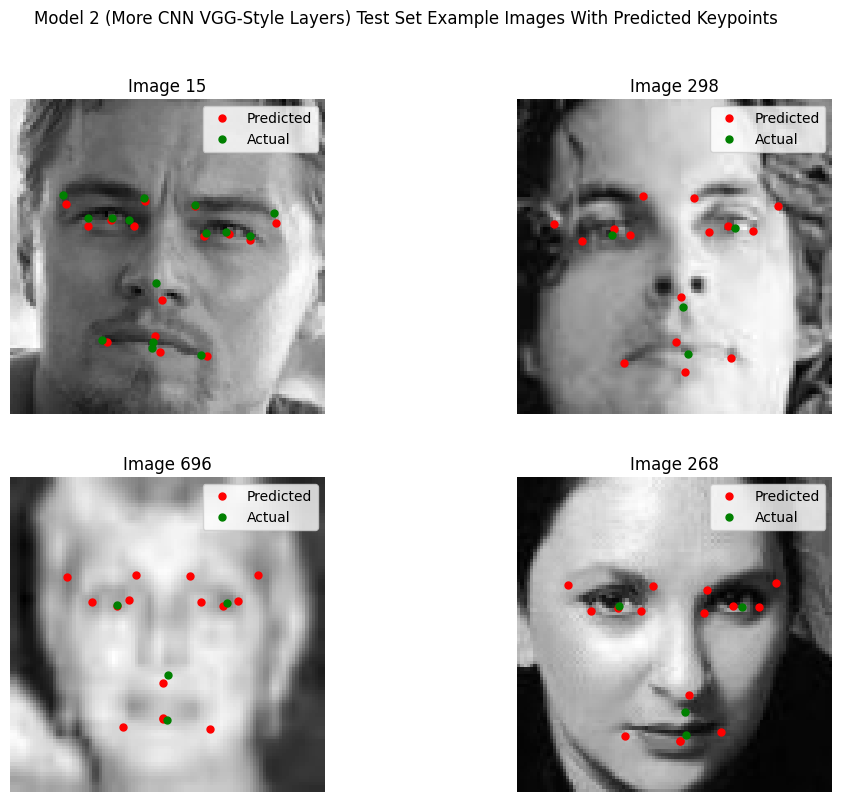

In [27]:
# analyze test results
import random
inds = random.sample(range(len(y_test)), 4)
ctr = 0
fig, axes = plt.subplots(2,2, figsize=(12,9))
for i in range(2):
    for j in range(2):
        k = inds[ctr]
            
        # Prediction processing
        kps_pred = model2(X_test_torch[k].unsqueeze(0).to(device))
        kps_pred_np = kps_pred.detach().cpu().numpy().reshape(1, -1)
        # Flatten to 1D after inverse transform for easier plotting
        kps_pred_flat = keypoint_scaler.inverse_transform(kps_pred_np).flatten()
        
        # Actual processing (handling potential tensor/numpy mix)
        y_actual_raw = y_test[k].cpu().numpy() if torch.is_tensor(y_test[k]) else y_test[k]
        kps_act_flat = keypoint_scaler.inverse_transform(y_actual_raw.reshape(1, -1)).flatten()

        # Plotting
        axes[i,j].imshow(X_test[k].transpose(1, 2, 0).squeeze(), cmap='gray')
        axes[i,j].plot(kps_pred_flat[0::2], kps_pred_flat[1::2], 'ro', label='Predicted', markersize=5)
        axes[i,j].plot(kps_act_flat[0::2], kps_act_flat[1::2], 'go', label='Actual', markersize=5)
        
        axes[i,j].set_title(f'Image {k}')
        axes[i,j].legend()
        axes[i,j].axis('off') # Clean up the look

        ctr += 1

fig.suptitle('Model 2 (More CNN VGG-Style Layers) Test Set Example Images With Predicted Keypoints')
plt.show()